In [ ]:
#import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load Dataset
df = pd.read_csv("IPL.csv", low_memory=False)

### Dataset Overview

In [3]:
df.shape

(283678, 65)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283678 entries, 0 to 283677
Data columns (total 65 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         283678 non-null  int64  
 1   match_id           283678 non-null  int64  
 2   date               283678 non-null  object 
 3   match_type         283678 non-null  object 
 4   event_name         283678 non-null  object 
 5   innings            283678 non-null  int64  
 6   batting_team       283678 non-null  object 
 7   bowling_team       283678 non-null  object 
 8   over               283678 non-null  int64  
 9   ball               283678 non-null  int64  
 10  ball_no            283678 non-null  float64
 11  batter             283678 non-null  object 
 12  bat_pos            283678 non-null  int64  
 13  runs_batter        283678 non-null  int64  
 14  balls_faced        283678 non-null  int64  
 15  bowler             283678 non-null  object 
 16  va

## Important columns for analysis
1. match_id
2. innings
3. batting_team
4. bowling_team
5. over
6. batter
7. bowler
8. valid_ball
9. runs_total
10. wicket_kind
11. runs_target
12. player_of_match
13. match_won_by
14. toss_winner
15. toss_decision
16. venue
17. city
18. season

In [5]:
df.head()

,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_balls,team_wicket,new_batter,power_surge_start,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,141607,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,141608,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,2,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,141609,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,141610,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,3,0,NaN,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,141611,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,...,4,0,NaN,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False


In [6]:
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

extra_type           268185
wicket_kind          269572
player_out           269572
fielders             273433
runs_target          147168
review_batter        282771
team_reviewed        282771
review_decision      282771
umpire               282771
win_outcome            4724
superover_winner     279782
result_type          278954
method               279788
new_batter           270085
power_surge_start    283678
next_batter          270085
dtype: int64


In [7]:
# Number of seasons in the dataset

No_of_seasons = df.groupby('match_id')['season'].first().unique()
print(f'Data of {len(No_of_seasons)} have been mentioned in the dataset')

Data of 19 have been mentioned in the dataset


In [8]:
# Number of matches played in 19 seasons

df['match_id'].unique()

array([ 335982,  335983,  335984, ..., 1529265, 1529266, 1529267],
      shape=(1193,))

Each match is uniquely identified by a match id. This dataset contains details of 1193 matches, the total number of balls involved in 1193 matches is 283678 (i.e., the number of rows in the dataset)

In [9]:
# Number of matches per season

matches_per_season = df.groupby('season')['match_id'].nunique()
matches_per_season

season
2007/08    58
2009       57
2009/10    60
2011       73
2012       74
2013       76
2014       60
2015       59
2016       60
2017       59
2018       60
2019       60
2020/21    60
2021       60
2022       74
2023       74
2024       71
2025       74
2026       24
Name: match_id, dtype: int64

### Observation

The dataset contains approximately 200,000 rows and 65 columns. It includes match-level and ball-by-ball information spanning IPL seasons from 2008 to 2025. 

The data of 2026 is not totally provided, only data related to few matches is given.

In [10]:
# Cleaning Venue Column

df['venue'].unique()

array(['M Chinnaswamy Stadium',
       'Punjab Cricket Association Stadium, Mohali', 'Feroz Shah Kotla',
       'Wankhede Stadium', 'Eden Gardens', 'Sawai Mansingh Stadium',
       'Rajiv Gandhi International Stadium, Uppal',
       'MA Chidambaram Stadium, Chepauk', 'Dr DY Patil Sports Academy',
       'Newlands', "St George's Park", 'Kingsmead', 'SuperSport Park',
       'Buffalo Park', 'New Wanderers Stadium', 'De Beers Diamond Oval',
       'OUTsurance Oval', 'Brabourne Stadium',
       'Sardar Patel Stadium, Motera', 'Barabati Stadium',
       'Brabourne Stadium, Mumbai',
       'Vidarbha Cricket Association Stadium, Jamtha',
       'Himachal Pradesh Cricket Association Stadium', 'Nehru Stadium',
       'Holkar Cricket Stadium',
       'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium',
       'Subrata Roy Sahara Stadium',
       'Maharashtra Cricket Association Stadium',
       'Shaheed Veer Narayan Singh International Stadium',
       'JSCA International Stadium Complex', 'Sh

In [11]:
# There are many duplicate venues

df['venue'] = df['venue'].replace('Arun Jaitley Stadium', 'Arun Jaitley Stadium, Delhi')
df['venue'] = df['venue'].replace('Brabourne Stadium', 'Brabourne Stadium, Mumbai')
df['venue'] = df['venue'].replace('Dr DY Patil Sports Academy', 'Dr DY Patil Sports Academy, Mumbai')
df['venue'] = df['venue'].replace('Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium', 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam')
df['venue'] = df['venue'].replace('Eden Gardens', 'Eden Gardens, Kolkata')
df['venue'] = df['venue'].replace('Himachal Pradesh Cricket Association Stadium', 'Himachal Pradesh Cricket Association Stadium, Dharamsala')
df['venue'] = df['venue'].replace('M Chinnaswamy Stadium', 'M Chinnaswamy Stadium, Bengaluru')
df['venue'] = df['venue'].replace('M.Chinnaswamy Stadium', 'M Chinnaswamy Stadium, Bengaluru')
df['venue'] = df['venue'].replace('MA Chidambaram Stadium', 'MA Chidambaram Stadium, Chepauk, Chennai')
df['venue'] = df['venue'].replace('MA Chidambaram Stadium, Chepauk', 'MA Chidambaram Stadium, Chepauk, Chennai')
df['venue'] = df['venue'].replace('Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur', 'Maharaja Yadavindra Singh International Cricket Stadium, New Chandigarh')
df['venue'] = df['venue'].replace('Maharashtra Cricket Association Stadium', 'Maharashtra Cricket Association Stadium, Pune')
df['venue'] = df['venue'].replace('Punjab Cricket Association IS Bindra Stadium', 'Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh')
df['venue'] = df['venue'].replace('Punjab Cricket Association IS Bindra Stadium, Mohali', 'Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh')
df['venue'] = df['venue'].replace('Punjab Cricket Association Stadium, Mohali', 'Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh')
df['venue'] = df['venue'].replace('Rajiv Gandhi International Stadium', 'Rajiv Gandhi International Stadium, Uppal, Hyderabad')
df['venue'] = df['venue'].replace('Rajiv Gandhi International Stadium, Uppal', 'Rajiv Gandhi International Stadium, Uppal, Hyderabad')
df['venue'] = df['venue'].replace('Sawai Mansingh Stadium', 'Sawai Mansingh Stadium, Jaipur')
df['venue'] = df['venue'].replace('Wankhede Stadium', 'Wankhede Stadium, Mumbai')
df['venue'] = df['venue'].replace('Sheikh Zayed Stadium', 'Zayed Cricket Stadium, Abu Dhabi')
#Feroz Shah Kotla and Arun Jaitley Stadium, Delhi → same ground, renamed in 2019.
df['venue'] = df['venue'].replace('Feroz Shah Kotla', 'Arun Jaitley Stadium, Delhi')
#Sardar Patel Stadium, Motera and Narendra Modi Stadium, Ahmedabad → same venue, renamed in 2021.
df['venue'] = df['venue'].replace('Sardar Patel Stadium, Motera', 'Narendra Modi Stadium, Ahmedabad')

In [12]:
venue_count = len(df['venue'].unique())
print(f'There are a total of {venue_count} venues where IPL matches have been played so far')

There are a total of 37 venues where IPL matches have been played so far


### Observation

Duplicate values were found in venue column. These were handled appropriately before analysis.

## Season Analysis

### How many matches were played each season?

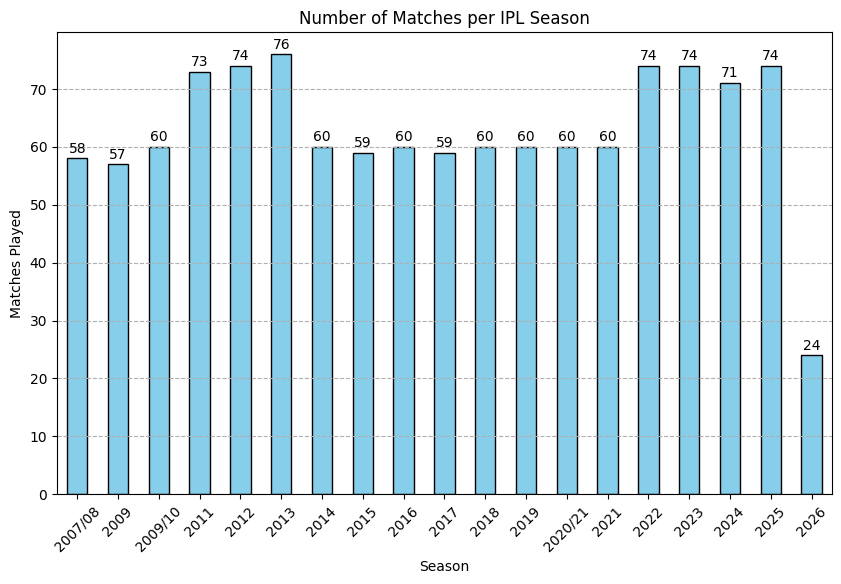

In [13]:
# Since we have already calculated the number of matches played in each season, 
# we can plot it for visualization

plt.figure(figsize=(10,6))
matches_per_season.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Number of Matches per IPL Season')
plt.xlabel('Season')
plt.ylabel('Matches Played')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')

for i, val in enumerate(matches_per_season):
    plt.text(i, val+1, round(val, 1), ha = 'center')

plt.show()

### Which season had the highest average score?

In [14]:
# per season, average of total runs in all matches

# Total runs per match
runs_per_match = (
    df.groupby(['season','match_id'])['runs_total']
      .sum()
      .reset_index(name='match_runs')
)

# Average runs per match per season
avg_runs_per_season = (
    runs_per_match.groupby('season')['match_runs']
      .mean()
      .reset_index(name='avg_score')
)

# Find season with highest average score
highest_avg = avg_runs_per_season.loc[avg_runs_per_season['avg_score'].idxmax()]

print("Season with highest average score:", highest_avg['season'])
print("Average score:", highest_avg['avg_score'])



Season with highest average score: 2024
Average score: 365.7887323943662


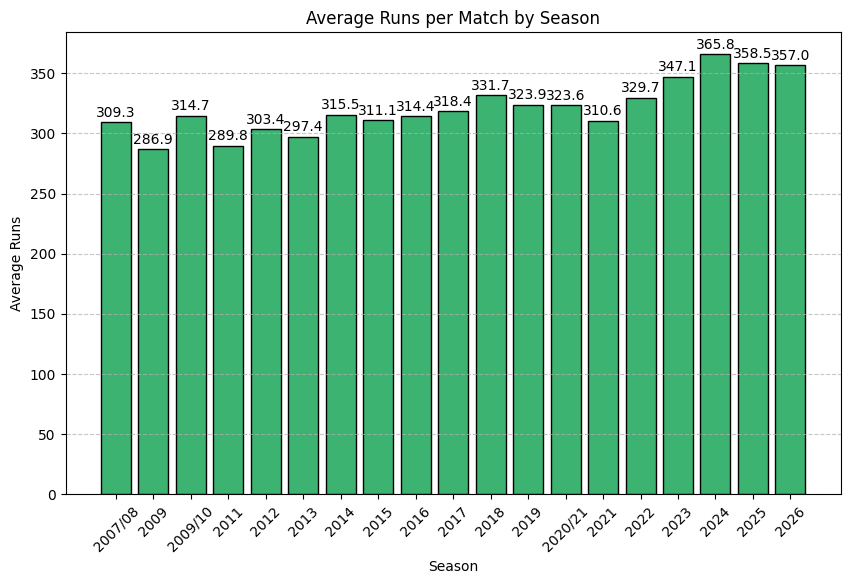

In [15]:
plt.figure(figsize=(10,6))
plt.bar(avg_runs_per_season['season'], avg_runs_per_season['avg_score'],
        color='mediumseagreen', edgecolor='black')

plt.title('Average Runs per Match by Season')
plt.xlabel('Season')
plt.ylabel('Average Runs')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, val in enumerate(avg_runs_per_season['avg_score']):
    plt.text(i, val+2, round(val,1), ha='center', va='bottom')

plt.savefig('avg_runs_per_match_by_season.png', format='png', dpi=300)

plt.show()

### How has the scoring changed over the years?

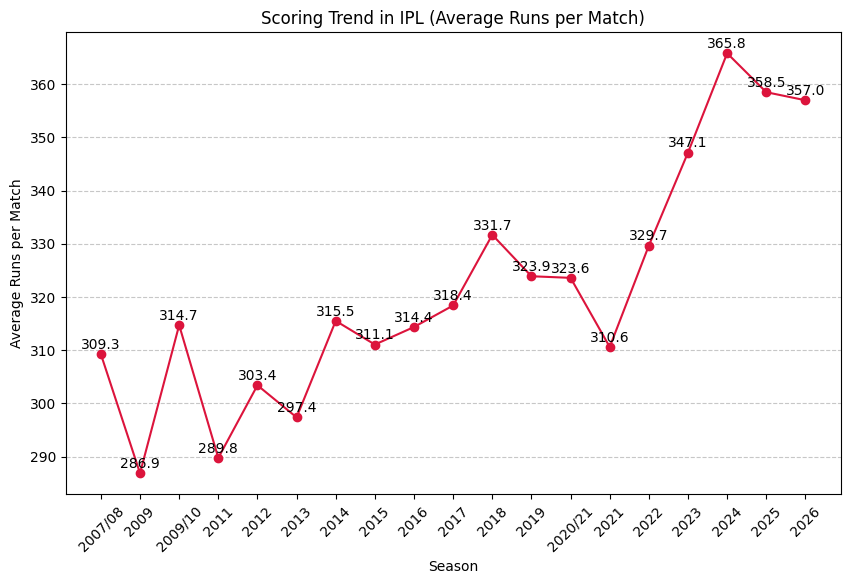

In [16]:
plt.figure(figsize=(10,6))
plt.plot(avg_runs_per_season['season'], avg_runs_per_season['avg_score'],
         marker='o', linestyle='-', color='crimson')

plt.title('Scoring Trend in IPL (Average Runs per Match)')
plt.xlabel('Season')
plt.ylabel('Average Runs per Match')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate values
for i, val in enumerate(avg_runs_per_season['avg_score']):
    plt.text(i, val+1, round(val,1), ha='center')

plt.savefig('scoring_trend_in_ipl.png', format='png', dpi=300)

plt.show()


 A shift from early 300s to mid‑350s average runs per match across IPL seasons highlights how the game has evolved 

## Team Analysis

### Which team has won the most matches?

In [17]:
df['batting_team'].unique()

array(['Kolkata Knight Riders', 'Royal Challengers Bangalore',
       'Chennai Super Kings', 'Kings XI Punjab', 'Rajasthan Royals',
       'Delhi Daredevils', 'Mumbai Indians', 'Deccan Chargers',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Sunrisers Hyderabad',
       'Rising Pune Supergiants', 'Gujarat Lions',
       'Rising Pune Supergiant', 'Delhi Capitals', 'Punjab Kings',
       'Lucknow Super Giants', 'Gujarat Titans',
       'Royal Challengers Bengaluru'], dtype=object)

In [18]:
df = df.replace('Delhi Daredevils', 'Delhi Capitals')
df = df.replace('Kings XI Punjab', 'Punjab Kings')
df = df.replace('Royal Challengers Bangalore', 'Royal Challengers Bengaluru')

In [19]:
teams_won = df.groupby('match_id')['match_won_by'].first()

# Some teams have discontinued playing in ipl
teams_won = teams_won[teams_won != 'Unknown']
teams_won = teams_won[teams_won != 'Deccan Chargers']
teams_won = teams_won[teams_won != 'Gujarat Lions']
teams_won = teams_won[teams_won != 'Pune Warriors']
teams_won = teams_won[teams_won != 'Rising Pune Supergiant']
teams_won = teams_won[teams_won != 'Kochi Tuskers Kerala']
teams_won = teams_won[teams_won != 'Rising Pune Supergiants']

matches_won = teams_won.value_counts()
print(matches_won)

match_won_by
Mumbai Indians                 152
Chennai Super Kings            144
Royal Challengers Bengaluru    136
Kolkata Knight Riders          135
Punjab Kings                   123
Delhi Capitals                 120
Rajasthan Royals               118
Sunrisers Hyderabad             95
Gujarat Titans                  39
Lucknow Super Giants            32
Name: count, dtype: int64


In [20]:
print(f'{matches_won.idxmax()} has won the most matches: {matches_won.max()}')

Mumbai Indians has won the most matches: 152


### Observation

Mumbai Indians have won the highest number of matches in IPL history, reflecting their long-term consistency and multiple championship-winning campaigns.

### Which team has the highest win percentage?

Win percentage = No. of wins / Total number of matches played

In [21]:
matches_played = (
    df.groupby(['match_id', 'batting_team'])
      .size()
      .reset_index()
      .groupby('batting_team')['match_id']
      .nunique()
)

teams_to_remove = [
    'Deccan Chargers',
    'Gujarat Lions',
    'Pune Warriors',
    'Rising Pune Supergiant',
    'Kochi Tuskers Kerala',
    'Rising Pune Supergiants'
]

total_matches_played = matches_played.drop(teams_to_remove, errors='ignore')
print(total_matches_played)

batting_team
Chennai Super Kings            256
Delhi Capitals                 270
Gujarat Titans                  64
Kolkata Knight Riders          269
Lucknow Super Giants            63
Mumbai Indians                 282
Punjab Kings                   268
Rajasthan Royals               239
Royal Challengers Bengaluru    275
Sunrisers Hyderabad            200
Name: match_id, dtype: int64


In [22]:
team_stats = pd.DataFrame({
    'matches_played': total_matches_played,
    'wins': matches_won
})

# Calculate win percentage
team_stats['win_percentage'] = (team_stats['wins'] / team_stats['matches_played']) * 100

print(team_stats)

                             matches_played  wins  win_percentage
Chennai Super Kings                     256   144       56.250000
Delhi Capitals                          270   120       44.444444
Gujarat Titans                           64    39       60.937500
Kolkata Knight Riders                   269   135       50.185874
Lucknow Super Giants                     63    32       50.793651
Mumbai Indians                          282   152       53.900709
Punjab Kings                            268   123       45.895522
Rajasthan Royals                        239   118       49.372385
Royal Challengers Bengaluru             275   136       49.454545
Sunrisers Hyderabad                     200    95       47.500000


In [23]:
top_team = team_stats['win_percentage'].idxmax()
top_percentage = team_stats['win_percentage'].max()

print(f"{top_team} has the highest win percentage: {top_percentage:.2f}%")

Gujarat Titans has the highest win percentage: 60.94%


### Observation

GT leads IPL history in win percentage, showing remarkable consistency despite being a newer entrant.

### Which team performs best while chasing?

number of matches won when chased / number of matches chased


In [24]:
# Number of maches each team chased

matches_chased = df.groupby(['match_id', 'bowling_team']).first()
matches_chased = matches_chased[matches_chased['innings']==2]
chased = matches_chased['batting_team'].value_counts()
print(chased)

batting_team
Delhi Capitals                 151
Kolkata Knight Riders          140
Mumbai Indians                 137
Royal Challengers Bengaluru    134
Rajasthan Royals               130
Punjab Kings                   129
Chennai Super Kings            116
Sunrisers Hyderabad             93
Gujarat Titans                  35
Deccan Chargers                 32
Lucknow Super Giants            27
Pune Warriors                   25
Gujarat Lions                   16
Rising Pune Supergiant           8
Rising Pune Supergiants          7
Kochi Tuskers Kerala             7
Name: count, dtype: int64


In [25]:
# Number of matches each team won while chasing

matches_chased['win_chase'] = matches_chased['batting_team'] == matches_chased['match_won_by']
wins_chased = matches_chased[matches_chased['win_chase']==True]
wins = wins_chased['batting_team'].value_counts()
print(wins)

batting_team
Kolkata Knight Riders          80
Mumbai Indians                 76
Delhi Capitals                 73
Royal Challengers Bengaluru    72
Rajasthan Royals               71
Chennai Super Kings            71
Punjab Kings                   68
Sunrisers Hyderabad            46
Gujarat Titans                 23
Gujarat Lions                  12
Lucknow Super Giants           12
Deccan Chargers                11
Pune Warriors                   6
Rising Pune Supergiants         5
Rising Pune Supergiant          5
Kochi Tuskers Kerala            4
Name: count, dtype: int64


In [26]:
chasing_percentage = pd.DataFrame({
    'chased': chased,
    'won': wins
})

teams_to_remove = [
    'Deccan Chargers',
    'Gujarat Lions',
    'Pune Warriors',
    'Rising Pune Supergiant',
    'Kochi Tuskers Kerala',
    'Rising Pune Supergiants'
]

chasing_percentage = chasing_percentage.drop(teams_to_remove, errors='ignore')

chasing_percentage['percentage'] = chasing_percentage['won']/chasing_percentage['chased']*100
print(chasing_percentage)

                             chased  won  percentage
batting_team                                        
Chennai Super Kings             116   71   61.206897
Delhi Capitals                  151   73   48.344371
Gujarat Titans                   35   23   65.714286
Kolkata Knight Riders           140   80   57.142857
Lucknow Super Giants             27   12   44.444444
Mumbai Indians                  137   76   55.474453
Punjab Kings                    129   68   52.713178
Rajasthan Royals                130   71   54.615385
Royal Challengers Bengaluru     134   72   53.731343
Sunrisers Hyderabad              93   46   49.462366


In [27]:
best_team = chasing_percentage['percentage'].idxmax()
best_percentage = chasing_percentage['percentage'].max()
print(f'{best_team} has the performed the best while chasing: {best_percentage}')

Gujarat Titans has the performed the best while chasing: 65.71428571428571


### Observation
GT leads IPL in chasing win percentage, showcasing efficiency under pressure, while CSK remains the most consistent chaser across seasons

### Home Ground advantage?

In [28]:
df['city'].unique()

array(['Bangalore', 'Chandigarh', 'Delhi', 'Mumbai', 'Kolkata', 'Jaipur',
       'Hyderabad', 'Chennai', 'Cape Town', 'Port Elizabeth', 'Durban',
       'Centurion', 'East London', 'Johannesburg', 'Kimberley',
       'Bloemfontein', 'Ahmedabad', 'Cuttack', 'Nagpur', 'Dharamsala',
       'Kochi', 'Indore', 'Visakhapatnam', 'Pune', 'Raipur', 'Ranchi',
       'Abu Dhabi', 'Unknown', 'Rajkot', 'Kanpur', 'Bengaluru', 'Dubai',
       'Sharjah', 'Navi Mumbai', 'Lucknow', 'Guwahati', 'Mohali',
       'New Chandigarh'], dtype=object)

In [29]:
df['city'] = df['city'].replace('Bangalore', 'Bengaluru')
df['city'] = df['city'].replace('Chandigarh', 'New Chandigarh')
df['city'] = df['city'].replace('Navi Mumbai', 'Mumbai')
df['city'] = df['city'].replace('Mohali', 'New Chandigarh')

In [30]:
homeGround = {
    'Chennai Super Kings': 'Chennai',
    'Delhi Capitals': 'Delhi',
    'Gujarat Titans': 'Ahmedabad',
    'Kolkata Knight Riders': 'Kolkata',
    'Lucknow Super Giants': 'Lucknow',
    'Mumbai Indians': 'Mumbai',
    'Punjab Kings': 'New Chandigarh',
    'Rajasthan Royals': 'Jaipur',
    'Royal Challengers Bengaluru': 'Bengaluru',
    'Sunrisers Hyderabad': 'Hyderabad'
}

In [31]:
matches = df.groupby('match_id').first().copy()

In [32]:
# Total Number of matches played at home and played away from home

team1 = matches[['batting_team', 'city']].copy()
team1.columns = ['team', 'city']

team2 = matches[['bowling_team', 'city']].copy()
team2.columns = ['team', 'city']

all_teams = pd.concat([team1, team2], ignore_index=True)

all_teams['homeGround'] = all_teams['team'].map(homeGround)
all_teams['is_home'] = all_teams['city'] == all_teams['homeGround']

played_home = all_teams[all_teams['is_home']]['team'].value_counts()

played_away = all_teams[~all_teams['is_home']]['team'].value_counts()

In [33]:
# Number of matches won when playing at home and 
# Number of matches won when playing away from home

winner = matches[['match_won_by', 'city']].copy()

winner['homeGround'] = winner['match_won_by'].map(homeGround)
winner['is_home_win'] = winner['city'] == winner['homeGround']

home_wins = winner[winner['is_home_win']]['match_won_by'].value_counts()

away_wins = winner[~winner['is_home_win']]['match_won_by'].value_counts()

In [34]:
# Tabularize the results

home_ground = pd.DataFrame({
    'played-at-home': played_home,
    'home-wins': home_wins,
    'played-away-from-home': played_away,
    'away-wins': away_wins,
    'total-wins': matches['match_won_by'].value_counts()
}).fillna(0)

teams_to_remove = [
    'Unknown',
    'Deccan Chargers',
    'Gujarat Lions',
    'Pune Warriors',
    'Rising Pune Supergiant',
    'Rising Pune Supergiants',
    'Kochi Tuskers Kerala'
]

home_ground = home_ground.drop(teams_to_remove, errors='ignore')

In [35]:
# Calculate the percentage

home_ground['home_win_pct'] = (
    home_ground['home-wins'] /
    home_ground['played-at-home'] * 100
).round(2)

home_ground['away_win_pct'] = (
    home_ground['away-wins'] /
    home_ground['played-away-from-home'] * 100
).round(2)

In [36]:
# advantage

home_ground['home_advantage'] = (
    home_ground['home_win_pct'] -
    home_ground['away_win_pct']
)

home_ground = home_ground.sort_values(
    'home_advantage',
    ascending=False
)

In [37]:
home_ground

,played-at-home,home-wins,played-away-from-home,away-wins,total-wins,home_win_pct,away_win_pct,home_advantage
Sunrisers Hyderabad,65.0,38.0,136.0,57,95,58.46,41.91,16.55
Rajasthan Royals,62.0,38.0,178.0,80,118,61.29,44.94,16.35
Chennai Super Kings,80.0,53.0,177.0,91,144,66.25,51.41,14.84
Mumbai Indians,117.0,70.0,165.0,82,152,59.83,49.70,10.13
Kolkata Knight Riders,98.0,54.0,171.0,81,135,55.10,47.37,7.73
Punjab Kings,73.0,36.0,196.0,87,123,49.32,44.39,4.93
Royal Challengers Bengaluru,98.0,48.0,177.0,88,136,48.98,49.72,-0.74
Delhi Capitals,89.0,37.0,182.0,83,120,41.57,45.60,-4.03
Gujarat Titans,24.0,13.0,40.0,26,39,54.17,65.00,-10.83
Lucknow Super Giants,23.0,9.0,40.0,23,32,39.13,57.50,-18.37


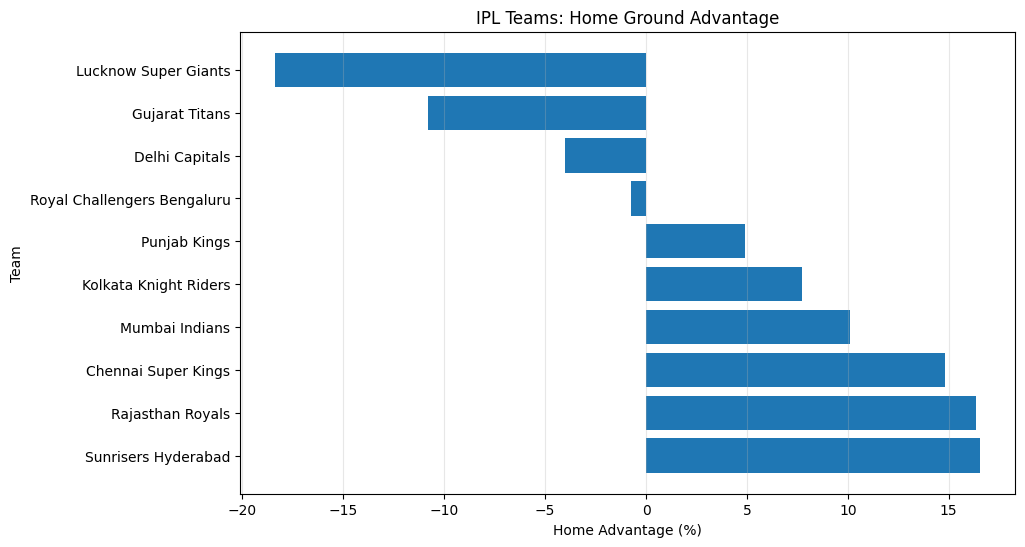

In [38]:
plt.figure(figsize=(10, 6))

plt.barh(
    home_ground.index,
    home_ground['home_advantage']
)

plt.xlabel('Home Advantage (%)')
plt.ylabel('Team')
plt.title('IPL Teams: Home Ground Advantage')
plt.grid(axis='x', alpha=0.3)

plt.savefig('Home_ground_adv.png', format='png', dpi=300)

plt.show()

### Observation
- CSK performs the best at homeGround with 66% wins but only 51% at other grounds.
- GT performs the best when away (65%) but only 54% wins at homeGround.
- SRH, RR, and CSk show the highest positive home advantage. This means they win significantly more at home compared to away, highlighting strong crowd support and familiarity with local conditions
- LSG and GT actually perform worse at home than away.
- Teams like DC, RCB, PKBS, KKR, and MI hover close to neutral, showing little difference between home and away performance. This indicates adaptability across venues.

## Batting Analysis

### Top 10 run scorers over all seasons

In [39]:
runs = df.groupby('batter')['runs_total'].sum()
runs = runs.sort_values(ascending=False)

In [40]:
runs.head(10)

batter
V Kohli           9242
RG Sharma         7463
S Dhawan          7119
DA Warner         6910
SK Raina          5780
MS Dhoni          5718
KL Rahul          5562
AM Rahane         5417
AB de Villiers    5354
CH Gayle          5336
Name: runs_total, dtype: int64

### Top 10 batters with Highest strike rates over all seasons

strike rate = Number of runs taken / Number of balls faced * 100

In [41]:
balls_faced = df.groupby('batter')['balls_faced'].sum()
balls_faced = balls_faced.sort_values(ascending = False)
strike_rate = pd.DataFrame({
    'runs': runs,
    'balls': balls_faced
})

strike_rate['rate'] = strike_rate['runs']/strike_rate['balls']*100
strike_rate = strike_rate[strike_rate['balls']>=100]
strike_rate = strike_rate.sort_values('rate', ascending = False)
strike_rate.head(10)

,runs,balls,rate
batter,,,
V Suryavanshi,465,198,234.848485
R Shepherd,233,108,215.740741
J Fraser-McGurk,406,193,210.362694
Priyansh Arya,689,347,198.559078
TH David,1052,556,189.208633
A Mhatre,423,227,186.343612
AD Russell,2825,1525,185.245902
PD Salt,1262,683,184.773060
Naman Dhir,521,286,182.167832


### Top 10 Players with Most Sixes across all seasons

In [42]:
sixers = df[df['runs_batter'] == 6]
sixers_count = sixers.groupby('batter').size().sort_values(ascending=False)

sixers_count.head(10)

batter
CH Gayle          359
RG Sharma         311
V Kohli           300
MS Dhoni          264
AB de Villiers    253
DA Warner         236
SV Samson         227
KA Pollard        224
AD Russell        223
KL Rahul          213
dtype: int64

### How has the sixers trend changed across seasons

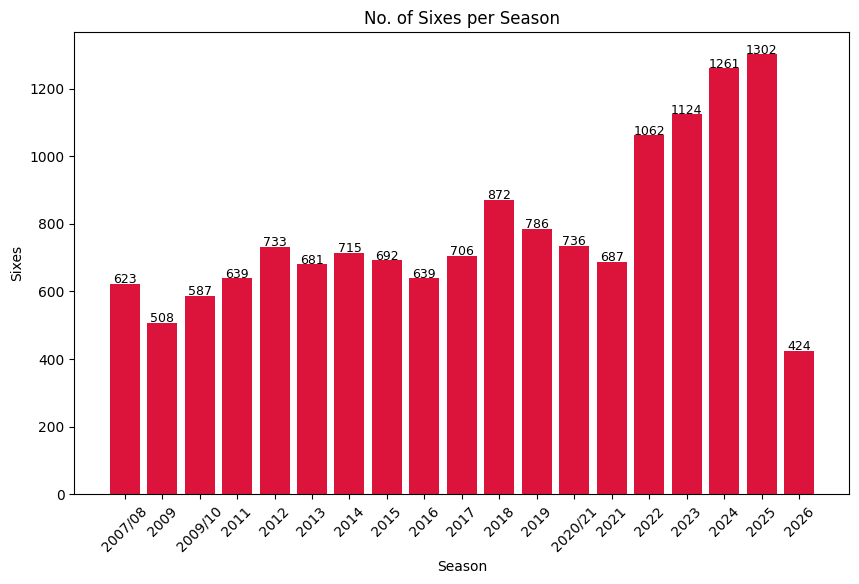

<Figure size 640x480 with 0 Axes>

In [43]:
sixers_per_season = sixers.groupby('season').size()
plt.figure(figsize=(10,6))
plt.bar(sixers_per_season.index, sixers_per_season.values, color='crimson')

for i, val in enumerate(sixers_per_season.values):
    plt.text(i, val+2, round(val,0), ha='center', fontsize=9)

plt.title('No. of Sixes per Season')
plt.xlabel('Season')
plt.ylabel('Sixes')
plt.xticks(rotation=45)
plt.show()

plt.savefig('sixers_per_season.png', format='png', dpi=300)

### Observation
The number of sixers per season struggled between 600s and 800s till 2021 but a drastic change can be see since then.

The number has rised to 1000s in 2022 and thereafter it has been increasing by 100 every year.

The 2026 data is incomplete.

### Top 10 batters with Most Boundaries

In [44]:
boundaries = df[df['runs_batter'] == 4]

boundaries_count = boundaries.groupby('batter').size().sort_values(ascending=False)

print(boundaries_count.head(10))

batter
V Kohli       799
S Dhawan      768
DA Warner     663
RG Sharma     653
AM Rahane     523
SK Raina      506
G Gambhir     492
RV Uthappa    481
KL Rahul      466
KD Karthik    466
dtype: int64


### How has the boundaries trend changed across seasons

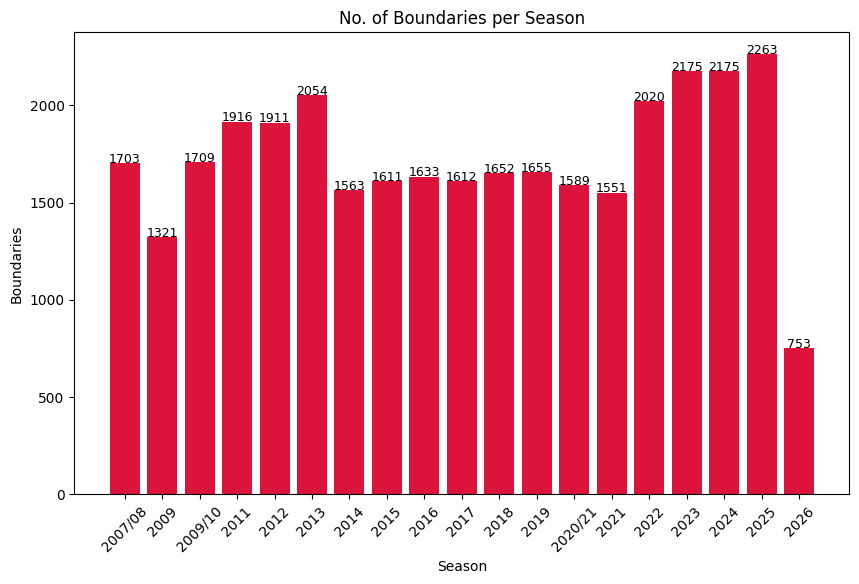

<Figure size 640x480 with 0 Axes>

In [45]:
boundaries_per_season = boundaries.groupby('season').size()
plt.figure(figsize=(10,6))
plt.bar(boundaries_per_season.index, boundaries_per_season.values, color='crimson')

for i, val in enumerate(boundaries_per_season.values):
    plt.text(i, val+2, round(val,0), ha='center', fontsize=9)

plt.title('No. of Boundaries per Season')
plt.xlabel('Season')
plt.ylabel('Boundaries')
plt.xticks(rotation=45)
plt.show()

plt.savefig('boundaries_per_season.png', format='png', dpi=300)

### Observation
The highest number of boundaries were hit in 2025.

Initially, the number went from 1700s to 2000s but dropped to mid 1550s in 2014 and thereafter maintained the same till 2021.

Then the trend went on increasing to 2250s in 2025

Data of 2026 is incomplete

### Orange Cap Winners in each season

Orange cap is awarded to the player who scores the maximum runs in the season

In [46]:
orange = (df.groupby(['season','batter'])['runs_total']
    .sum()
    .reset_index(name = 'runs-in-season')
    .sort_values(['runs-in-season','season'],ascending = False))
orange_cap = orange.loc[orange.groupby('season')['runs-in-season'].idxmax()].sort_values('season')
orange_cap

,season,batter,runs-in-season
115,2007/08,SE Marsh,644
229,2009,ML Hayden,626
446,2009/10,SR Tendulkar,665
502,2011,CH Gayle,638
684,2012,CH Gayle,762
852,2013,CH Gayle,778
1088,2014,RV Uthappa,681
1148,2015,DA Warner,589
1383,2016,V Kohli,998
1422,2017,DA Warner,670


### Observation
Virat Kohli scored 973 runs in 2016, the highest ever in a single IPL season.

David Warner has won the Orange Cap three times (2015, 2017, 2019), the most in IPL history.

## Bowling Analysis

### Top 10 Bowlers with Most wickets

In [47]:
df['wicket_kind'].value_counts()

wicket_kind
caught                   8880
bowled                   2379
run out                  1169
lbw                       861
caught and bowled         394
stumped                   378
retired hurt               18
hit wicket                 18
retired out                 6
obstructing the field       3
Name: count, dtype: int64

In [48]:
df['bowler'].value_counts()

bowler
R Ashwin         4868
SP Narine        4511
B Kumar          4505
RA Jadeja        4169
YS Chahal        3991
                 ... 
SN Khan             2
Ishan Kishan        1
Atharva Taide       1
YBK Jaiswal         1
AC Gilchrist        1
Name: count, Length: 564, dtype: int64

In [49]:
df['is_out'] = df['wicket_kind'].isnull()

wickets_count = (df[df['is_out'] == False].
    groupby('bowler').
    size().
    reset_index(name='No_wickets').
    sort_values('No_wickets', ascending=False))

wickets_count.head(10)

,bowler,No_wickets
476,YS Chahal,233
67,B Kumar,220
404,SP Narine,215
112,DJ Bravo,207
329,R Ashwin,205
185,JJ Bumrah,204
319,PP Chawla,201
397,SL Malinga,188
7,A Mishra,183
344,RA Jadeja,182


### Observation

YS Chahal is the highest wicket-taker in IPL history with 233 wickets.

### Top 10 Bowlers with Best economy rates

economy rate = runs conceded / overs bowled.

The lower the economy rate, the advantage to the bowling team

In [50]:
runs_conceded = df.groupby('bowler')['runs_total'].sum()
runs_conceded

bowler
A Ashish Reddy     400
A Badoni            50
A Chandila         245
A Choudhary        144
A Dananjaya         47
                  ... 
Yash Thakur        782
Yudhvir Singh      257
Yuvraj Singh      1091
Z Khan            2860
Zeeshan Ansari     334
Name: runs_total, Length: 564, dtype: int64

In [51]:
balls_bowled = df.groupby('bowler')['valid_ball'].size()
balls_bowled

bowler
A Ashish Reddy     270
A Badoni            35
A Chandila         234
A Choudhary        108
A Dananjaya         25
                  ... 
Yash Thakur        475
Yudhvir Singh      145
Yuvraj Singh       882
Z Khan            2276
Zeeshan Ansari     209
Name: valid_ball, Length: 564, dtype: int64

In [52]:
# considering the bowlers who have bowled for atleast 20 overs

overs_bowled = balls_bowled/6
overs_bowled = overs_bowled[overs_bowled >= 20 ]
overs_bowled

bowler
A Ashish Reddy     45.000000
A Chandila         39.000000
A Kamboj           52.833333
A Kumble          163.833333
A Mishra          574.000000
                     ...    
Yash Thakur        79.166667
Yudhvir Singh      24.166667
Yuvraj Singh      147.000000
Z Khan            379.333333
Zeeshan Ansari     34.833333
Name: valid_ball, Length: 338, dtype: float64

In [53]:
economy_rates = pd.DataFrame({
    'runs_conceded': runs_conceded,
    'overs_bowled': overs_bowled
})

economy_rates['economy'] = economy_rates['runs_conceded']/economy_rates['overs_bowled']

In [54]:
# setting a threshold of 50 overs -
# filters out part‑timers but still includes bowlers who played a single season regularly.

economy_rates = economy_rates[economy_rates['overs_bowled']>=50]
economy_rates = economy_rates.sort_values('economy', ascending=True)
economy_rates.head(10)

,runs_conceded,overs_bowled,economy
bowler,,,
A Kumble,1089,163.833333,6.646999
GD McGrath,366,54.833333,6.674772
M Muralitharan,1765,263.500000,6.698292
J Yadav,447,66.333333,6.738693
RE van der Merwe,515,75.833333,6.791209
DW Steyn,2583,380.333333,6.791411
SP Narine,5135,751.833333,6.829971
DL Vettori,894,130.833333,6.833121
J Botha,818,118.166667,6.922426


In [55]:
# setting a threshold of 100 overs - 
# highlights only bowlers who have bowled across multiple seasons or been consistent regulars.

economy_rates = economy_rates[economy_rates['overs_bowled']>=100]
economy_rates = economy_rates.sort_values('economy', ascending=True)
economy_rates.head(10)

,runs_conceded,overs_bowled,economy
bowler,,,
A Kumble,1089,163.833333,6.646999
M Muralitharan,1765,263.500000,6.698292
DW Steyn,2583,380.333333,6.791411
SP Narine,5135,751.833333,6.829971
DL Vettori,894,130.833333,6.833121
J Botha,818,118.166667,6.922426
SL Malinga,3486,495.666667,7.032952
Harbhajan Singh,4101,582.666667,7.038330
R Ashwin,5721,811.333333,7.051356


## Venue Analysis

### Highest Scoring Grounds

In [56]:
# Total runs per match at each venue

venue_avg = (
    df.groupby(['venue','match_id'])['runs_total'].sum()
      .groupby('venue').mean()
      .sort_values(ascending=False)
)

venue = venue_avg.idxmax()
score = venue_avg.max()

print(f'{venue} has the highest runs per match\n')
venue_avg.head(10)

Narendra Modi Stadium, Ahmedabad has the highest runs per match



venue
Narendra Modi Stadium, Ahmedabad                                           346.804348
Brabourne Stadium, Mumbai                                                  344.629630
Maharaja Yadavindra Singh International Cricket Stadium, New Chandigarh    337.615385
Saurashtra Cricket Association Stadium                                     333.300000
Wankhede Stadium, Mumbai                                                   332.968750
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow      331.625000
Himachal Pradesh Cricket Association Stadium, Dharamsala                   331.266667
M Chinnaswamy Stadium, Bengaluru                                           328.970588
Arun Jaitley Stadium, Delhi                                                328.727273
Barsapara Cricket Stadium, Guwahati                                        326.500000
Name: runs_total, dtype: float64

### Does winning the toss actually help?

In [57]:
total = df['match_id'].nunique()
refined = df.groupby('match_id').first()
refined['toss'] = refined['toss_winner']==refined['match_won_by']

In [58]:
true = refined['toss'].sum()
possibility = true/total
possibility*100

np.float64(50.79631181894384)

### Observation

Winning the toss translates into winning the match only about ~51% of the time in IPL history.

Across IPL seasons, toss winners win only ~51% of matches, showing that while toss decisions offer a minor edge, match outcomes are still driven largely by team performance.